IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios registrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos consiste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [423]:
# Descarga de datos desde Kaggle

### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [425]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os #Lo importo para poder interactuar con el sistema operativo

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los distintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de artistas y diseñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

In [428]:
carpeta = r"C:\Users\mtorr\OneDrive\Escritorio\Intro\IMT2200-Constanza-Hernandez\Tarea 01\dataset-bgg_"

df = pd.read_csv(os.path.join(carpeta, "bgg_GameItem.csv")) 

#Encontré una forma para decodificar usando una función, pero, a pesar de intentarlo de distintas formas, las celdas con más de un código se
#me devolvían como una celda vacía o como "NaN" o "None, así que preferí hacerlo una por una al no ser tantas.

#Decodificación de columna game_type:
lookup = pd.read_csv(os.path.join(carpeta, "bgg_GameType.csv"))
diccionario = dict(zip(lookup["bgg_id"].astype(str).str.strip(), lookup["name"])) 
nueva_columna = [] #Se crea una columna a la que se le van a ir agregando los datos.
for celda in df["game_type"]:
    if pd.isna(celda) or str(celda).strip() == "":
        nueva_columna.append("")  
    else:
        codigos = [c.strip() for c in str(celda).split(",")] 
        nombres = [diccionario.get(c, c) for c in codigos] 
        nueva_columna.append(", ".join(nombres))

df["game_type"] = nueva_columna #La nueva columna toma el lugar de la columna anterior, dejando los dat


#Decodificación de columna publisher:
lookup = pd.read_csv(os.path.join(carpeta, "bgg_Publisher.csv"))
diccionario = dict(zip(lookup["bgg_id"].astype(str).str.strip(), lookup["name"])) 
nueva_columna = [] 
for celda in df["publisher"]:
    if pd.isna(celda) or str(celda).strip() == "":
        nueva_columna.append("")  
    else:
        codigos = [c.strip() for c in str(celda).split(",")] 
        nombres = [diccionario.get(c, c) for c in codigos] 
        nueva_columna.append(", ".join(nombres))

df["publisher"] = nueva_columna 

#Decodificación de columna category:
lookup = pd.read_csv(os.path.join(carpeta, "bgg_Category.csv"))
diccionario = dict(zip(lookup["bgg_id"].astype(str).str.strip(), lookup["name"])) 
nueva_columna = [] 
for celda in df["category"]:
    if pd.isna(celda) or str(celda).strip() == "":
        nueva_columna.append("")  
    else:
        codigos = [c.strip() for c in str(celda).split(",")] 
        nombres = [diccionario.get(c, c) for c in codigos] 
        nueva_columna.append(", ".join(nombres))

df["category"] = nueva_columna 

#Decodificación de columna mechanic:
lookup = pd.read_csv(os.path.join(carpeta, "bgg_Mechanic.csv"))
diccionario = dict(zip(lookup["bgg_id"].astype(str).str.strip(), lookup["name"])) 
nueva_columna = [] 
for celda in df["mechanic"]:
    if pd.isna(celda) or str(celda).strip() == "":
        nueva_columna.append("")  
    else:
        codigos = [c.strip() for c in str(celda).split(",")] 
        nombres = [diccionario.get(c, c) for c in codigos] 
        nueva_columna.append(", ".join(nombres))

df["mechanic"] = nueva_columna 

#Decodificación de columna family:
lookup = pd.read_csv(os.path.join(carpeta, "bgg_GameFamily.csv"))
diccionario = dict(zip(lookup["bgg_id"].astype(str).str.strip(), lookup["name"])) 
nueva_columna = [] 
for celda in df["family"]:
    if pd.isna(celda) or str(celda).strip() == "":
        nueva_columna.append("")  
    else:
        codigos = [c.strip() for c in str(celda).split(",")] 
        nombres = [diccionario.get(c, c) for c in codigos] 
        nueva_columna.append(", ".join(nombres))

df["family"] = nueva_columna 

###Como entre los archivos no hay "bgg_Artist.csv" o "bgg_Designer.csv" y en "bgg_GameItem.csv" no hay una columna llamada "person", 
###utilizaré el archivo "bgg_Person.csv" para decodificar las columas "artist" y "designer"

#Decodificación de columna artist:
lookup = pd.read_csv(os.path.join(carpeta, "bgg_Person.csv"))
diccionario = dict(zip(lookup["bgg_id"].astype(str).str.strip(), lookup["name"])) 
nueva_columna = [] 
for celda in df["artist"]:
    if pd.isna(celda) or str(celda).strip() == "":
        nueva_columna.append("")  
    else:
        codigos = [c.strip() for c in str(celda).split(",")] 
        nombres = [diccionario.get(c, c) for c in codigos] 
        nueva_columna.append(", ".join(nombres))

df["artist"] = nueva_columna 

#Decodificación de columna designer:
lookup = pd.read_csv(os.path.join(carpeta, "bgg_Person.csv"))
diccionario = dict(zip(lookup["bgg_id"].astype(str).str.strip(), lookup["name"])) 
nueva_columna = [] 
for celda in df["designer"]:
    if pd.isna(celda) or str(celda).strip() == "":
        nueva_columna.append("")  
    else:
        codigos = [c.strip() for c in str(celda).split(",")] 
        nombres = [diccionario.get(c, c) for c in codigos] 
        nueva_columna.append(", ".join(nombres))

df["designer"] = nueva_columna 



# Guardar resultado
df.to_csv(os.path.join(carpeta, "bgg_GameItem_decodificado.csv"), index=False, encoding="utf-8")

df.head()

,bgg_id,name,year,game_type,designer,artist,publisher,min_players,max_players,min_players_rec,...,stddev_rating,bayes_rating,complexity,language_dependency,bga_id,dbpedia_id,luding_id,spielen_id,wikidata_id,wikipedia_id
0,1,Die Macher,1986.0,Strategy Game,Karl-Heinz Schmiel,"Marcus Gschwendtner, Harald Lieske","Hans im Glück, Moskito Spiele, Ediciones MasQu...",3.0,5.0,4.0,...,1.57510,7.06367,4.3144,1.166667,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Dragonmaster,1981.0,Strategy Game,"G. W. ""Jerry"" D'Arcey",Bob Pepper,"E.S. Lowe, Milton Bradley",3.0,4.0,3.0,...,1.46752,5.76599,1.9636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Samurai,1998.0,Strategy Game,Reiner Knizia,Franz Vohwinkel,"Fantasy Flight Games, Hans im Glück, 999 Games...",2.0,4.0,2.0,...,1.19279,7.22869,2.4784,1.006579,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Tal der Könige,1992.0,Strategy Game,Christian Beierer,Thomas di Paolo,KOSMOS,2.0,4.0,2.0,...,1.23667,5.66660,2.6667,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Acquire,1964.0,Strategy Game,Sid Sackson,"Scott Okumura, Peter Whitley","3M, The Avalon Hill Game Co, Avalon Hill, Duja...",2.0,6.0,3.0,...,1.33603,7.12541,2.4985,1.095890,NaN,NaN,NaN,NaN,NaN,NaN


**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



Los archivos que comienza con bgg_ utilizan 19,3 MB de espacio en el disco, mientras que el DataFrame utiliza 17.5 MB. El espacio que utiliza el DataFrame actual, es el mismo espacio que utiliza el que está dentro de la carpeta, pues, al haberse reemplazado datos en este, no se le sumó peso. Por lo tanto, esta diferencia se debe a que, al hablar del espacio que utilizan las documentos CSV por separado, también se cuenta el espacio de "bgg_GameItems.csv" y se le suma el peso de cada archivo de traducción de códigos. 
En conclusión, por un lado contamos el espacio que utiliza el DataFrame por si solo y por el otro el que utiliza acompañado de otros archivos, lo que le suma peso.

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?

In [432]:
df["year"].value_counts().sort_index() #Esto sirve para contar cuántos juegos se crearon en cada año y, a la vez, ordena los años de menor a mayor.

year
-3500.0       1
-3000.0       4
-2600.0       2
-2200.0       1
-2000.0       2
           ... 
 2022.0    4436
 2023.0    2597
 2024.0     261
 2025.0      16
 2026.0       2
Name: count, Length: 334, dtype: int64

El rango de años con el que estamos trabajando es de -3.500 a 2026. Hay valores que no tienen sentido pues los años no se pueden escribir en negativo. 
También se puede ver que supuestamente se crearon 2 juegos en 2026, eso no tiene sentido, pues ese año aún no llega.
En la limpieza de datos voy a eliminar todos los años con valor negativo y el 2026.

In [434]:
df_filtrado = df[(df["year"] >= 0) & (df["year"] <= 2025)] #Aquí seleccionamos el rango
df_filtrado["year"].value_counts().sort_index()

year
41.0         1
220.0        1
300.0        1
400.0        2
500.0        1
          ... 
2021.0    4693
2022.0    4436
2023.0    2597
2024.0     261
2025.0      16
Name: count, Length: 320, dtype: int64

Podemos apreciar que ahora el rango se redujo a: desde el año 41 hasta el año 2025.

**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

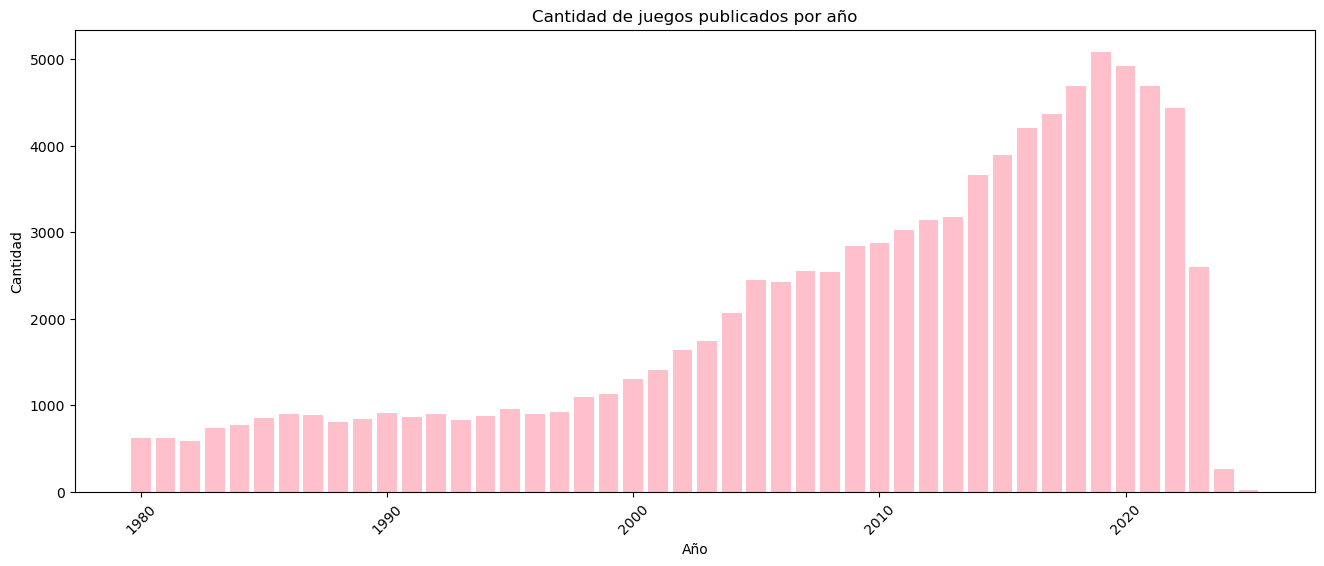

In [437]:
años_filtrados = df.loc[(df["year"] >= 1980) & (df["year"] <= 2025)] #Así selecciono un rango 
conteo = años_filtrados["year"].value_counts().sort_index()
#Me basé en la ayudantía 2:
plt.figure(figsize=(16, 6))
plt.bar(conteo.index, conteo.values, color = "pink")
plt.title('Cantidad de juegos publicados por año')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()


La tendencia que se puede ver que hasta el año 2000 no se creaban más de, aproximadamente, 1000 juegos por año, desde ahí se puede ver un aumento evidente en su creación, llegando a tu punto máximo en 2019, desde donde se ha visto una disminución importante, especialmente en 2023 y 2024 (Aún no termina 2025, así que no se puede determinar con certeza) 

**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

In [440]:
conteo = años_filtrados["year"].value_counts().sort_index()
diferencias = conteo.diff().abs()   #diff calcula la diferencia entre la cantidad de publicaciones estre un año y el anterior.
                                    #abs devuelve el valor absoluto, por lo que siempre volvería un valor positivo representando la diferencia.
max_diff = diferencias.max() #max devuelve el elemento mayor, indicándonos el mayor aumento en la publicación de juegos entre dos años distintos.
año_actual = diferencias.idxmax() #idxmax devuelve el año año donde está este aumento máximo
año_anterior = año_actual - 1
print(f"La mayor diferencia de juegos fue entre {año_anterior} y {año_actual}, con una diferencia de {max_diff} juegos.")

La mayor diferencia de juegos fue entre 2023.0 y 2024.0, con una diferencia de 2336.0 juegos.


### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

In [443]:
#De aquí en adelante voy a usar el DataFrame de años_filtrados.
#Por lo que entiendo, debo trabajar con los datos que tengan valores válidos para min_time, max_time y complexity al mismo tiempo,
#por lo que eliminaré las filas que no cumplan con todas las condiciones, acotando la cantidad de datos a trabajar.
datos_validos = años_filtrados.loc[(años_filtrados["min_time"].notnull()) & (años_filtrados["max_time"].notnull()) & (años_filtrados["complexity"].notnull())]
#isnull y notnull nos indican explicitamente si un valor es valido o no, en este caso di como condición que el dato fuera "notnull", que no sea nulo.
datos_validos.to_csv(os.path.join(carpeta, "GameItem_Filtrado.csv"), index=False, encoding="utf-8")
print("Se guardó") #Dejé esto para saber si corrió la celda.

Se guardó


**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

In [445]:
df_actualizado = pd.read_csv(os.path.join(carpeta, "GameItem_Filtrado.csv"))
avg_time = df_actualizado[["min_time", "max_time"]].mean(axis=1) #mean promedia los valores entregados, en este caso el tiempo máximo y mínimo
df_actualizado.insert(17, "avg_time", avg_time) #Hice esto para que se guarde justo después de las columas de tiempo.

**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

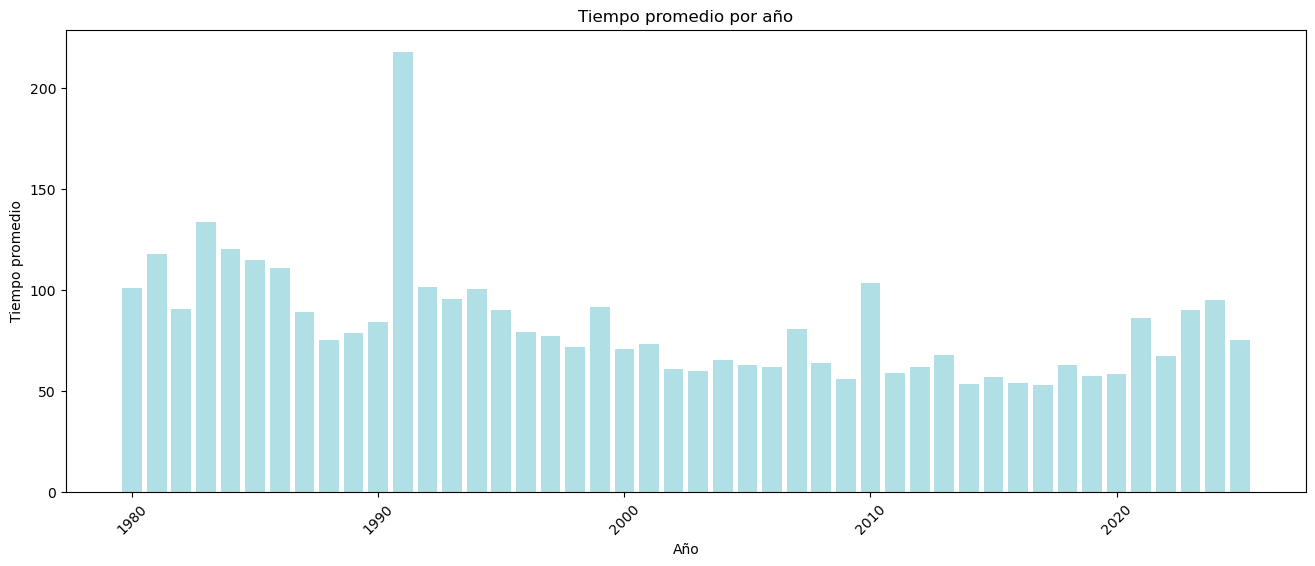

In [447]:
#Me basé en la ayudantía 2:
plt.figure(figsize=(16, 6))
tiempo_promedio = df_actualizado.groupby("year")["avg_time"].mean().sort_index() #Agrupo los datos del tiempo dependiendo de los años
plt.bar(tiempo_promedio.index, tiempo_promedio.values, color="powderblue")
plt.title("Tiempo promedio por año")
plt.xlabel("Año")
plt.ylabel("Tiempo promedio")
plt.xticks(rotation=45)
plt.show()

Se puede ver que no ha habido un aumento o una disminución lineal, ha variado independientemente de la época. Lo que sí es evidente es que el año 1991 tiene la duración promedio mayor y que al rededor del 2010 y 2020 los juegos han tenido una duración más corta.

**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

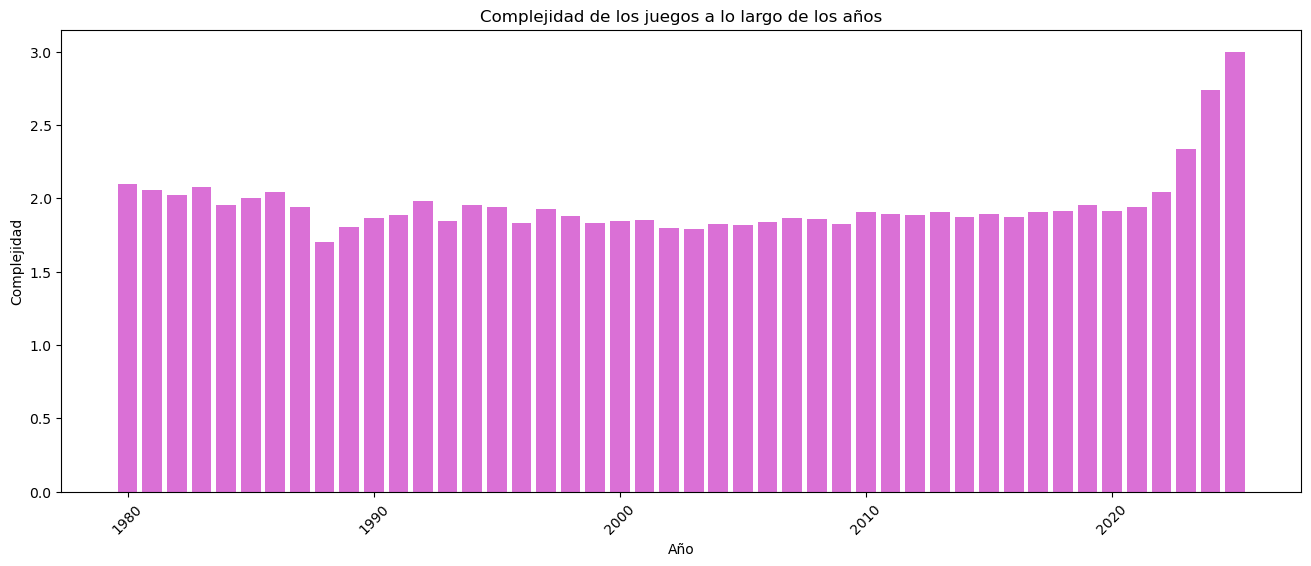

In [450]:
#Me basé en la ayudantía 2:
plt.figure(figsize=(16, 6))
complejidad = df_actualizado.groupby("year")["complexity"].mean().sort_index() #Agrupo los datos de la complejidad dependiendo de los años
plt.bar(complejidad.index, complejidad.values, color="orchid")
plt.title("Complejidad de los juegos a lo largo de los años")
plt.xlabel("Año")
plt.ylabel("Complejidad")
plt.xticks(rotation=45)
plt.show()

Aquí se puede apreciar que la complejidad de los juegos es muy constante a lo largo de los años, no tiene muchas variaciones. El unico aumento significativo que se puede ver es en los últimos años, del 2023 en adelante. También podremos apreciar una disminución de la dificultad en el año 1988, pero vuelve a aumentar en los años posteriores.

### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

In [453]:
df_actualizado["category"].value_counts()

category
Card Game                                                                                    1711
Abstract Strategy                                                                            1396
Wargame, World War II                                                                        1115
Party Game                                                                                    389
Dice                                                                                          379
                                                                                             ... 
Fantasy, Humor, Medieval, Nautical, Transportation                                              1
Bluffing, Card Game, Deduction, Fighting, Horror, Movies / TV / Radio theme, Novel-based        1
Deduction, Fighting, Horror                                                                     1
Bluffing, Card Game, Environmental                                                              1
Aviation / 

Al ver la cantidad de veces que cada categoría es asignada, podemos apreciar que las 5 más comunes son: "Card Game", "Abstract Strategy", "Warfame, World War II", "Party Game" y "Dice".
A continuación, haré un DataFrame con los 10 que más se repiten:

In [455]:
cantidad_categorias = df_actualizado["category"].value_counts()
cantidad_categorias.columns = ["category", "cantidad"] #Nombro las columnas del DataFrame
cantidad_categorias.head(5)

category
Card Game                1711
Abstract Strategy        1396
Wargame, World War II    1115
Party Game                389
Dice                      379
Name: count, dtype: int64

**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

In [457]:
#DataFrame de Card Game:
df_CardGame = df_actualizado[df_actualizado["category"] == "Card Game"]
df_año_CardGame = df_CardGame.groupby("year").size().reset_index(name="count")
df_año_CardGame["category"] = "Card Game" #Esto lo agrego para que, al juntar todos los DatFrames, haya columna de categoría

#DataFrame de Abstract Strategy:
df_AS = df_actualizado[df_actualizado["category"] == "Abstract Strategy"]
df_año_AS = df_AS.groupby("year").size().reset_index(name="count")
df_año_AS["category"] = "Abstract Strategy"

#DataFrame de Wargame, World War II:
df_wargame = df_actualizado[df_actualizado["category"] == "Wargame, World War II"]
df_año_wargame = df_wargame.groupby("year").size().reset_index(name="count")
df_año_wargame["category"] = "Wargame, World War II"

#DataFrame de Party Game:
df_party = df_actualizado[df_actualizado["category"] == "Party Game"]
df_año_party = df_party.groupby("year").size().reset_index(name="count")
df_año_party["category"] = "Party Game"

#DataFrame de Dice:
df_dice = df_actualizado[df_actualizado["category"] == "Dice"]
df_año_dice = df_dice.groupby("year").size().reset_index(name="count")
df_año_dice["category"] = "Dice"

#DataFrame unido:
df_total = pd.concat([df_año_CardGame, df_año_AS, df_año_wargame, df_año_party, df_año_dice], axis=0).reset_index(drop=True) 
#Agrego el reset para que el numero de la izquierda no empiece de 0 al cambiar de categoría
df_total = df_total[['category', 'year', 'count']] #Lo ordeno para que quede a mí gusto
df_total.head(50)


,category,year,count
0,Card Game,1980.0,1
1,Card Game,1981.0,3
2,Card Game,1982.0,7
3,Card Game,1983.0,7
4,Card Game,1984.0,4
5,Card Game,1985.0,2
6,Card Game,1986.0,8
7,Card Game,1987.0,5
8,Card Game,1988.0,8
9,Card Game,1989.0,4


**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


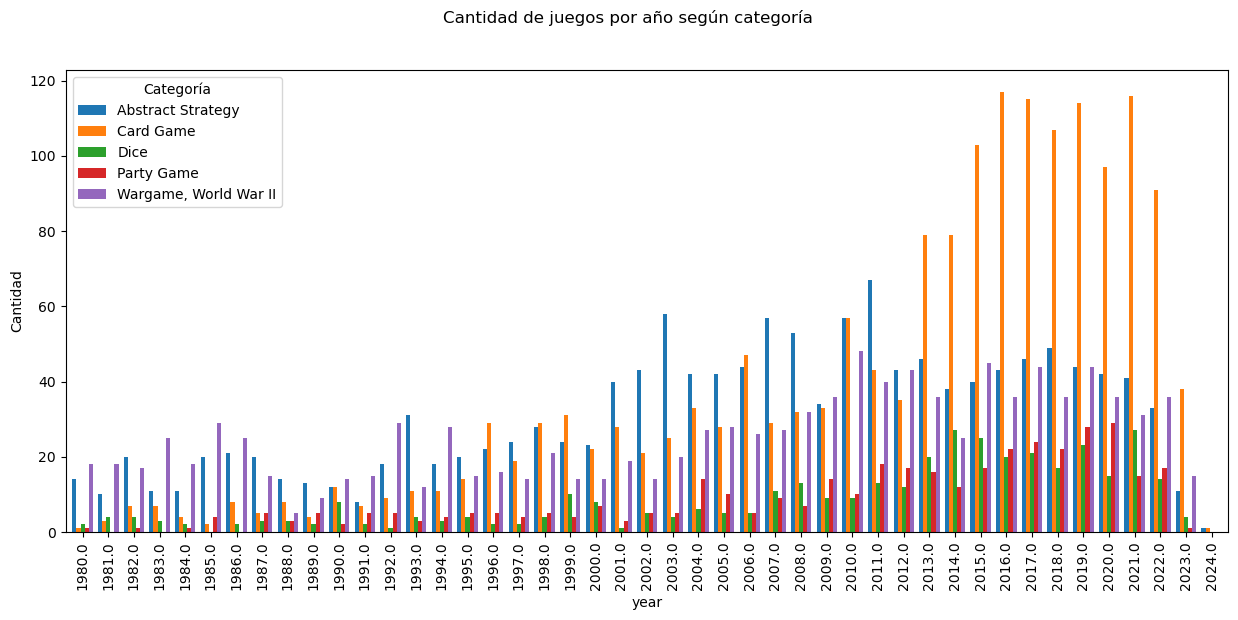

In [459]:
#Me basé en un código de la actividad 01:
df_pivot = df_total.pivot(index='year', columns='category', values='count').fillna(0)
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(111)
ax.set_ylabel('Cantidad')
ax.set_xlabel('Año')
fig.suptitle('Cantidad de juegos por año según categoría')
df_pivot.plot(kind='bar', ax=ax, width=0.8)  # width ajusta el ancho de las barras
ax.legend(title='Categoría')

plt.show()

Se puede ver que en los años 80 eran más populares los juegos con categoría "Wargame, World War II" o "Abstract Strategy", mientras que en los últimos años se han popularizado más lo que tienen como categoría "Card Game"

### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?

Considero que algunos problemas que tenían los datos es que había bastantes valores que no eran válidos o eran nulos y, a su vez, había columnas que eran muy poco utilizadas, lo que hacía más tedioso el poder enfocarse en los datos más relevantes.